In [1]:
import pandas as pd
import json
import re
import matplotlib.pyplot as plt
from utils.plot_functions import plot_yearly_bar_chart
from utils.utils import normalize_text, split_semicolon_list, split_pipe_list, matches_any_pattern, normalize_name

In [2]:
DATASET_PATH = "data/openalex_ai_healthcare_publications_1980_2026_filtered_2.csv"

In [3]:
publications_df = pd.read_csv(DATASET_PATH)

#### **4. Medical–Technical Institution Collaboration**

#### **4.1 Overall medical-technical institution collaboration**
This section computes the overall proportion of publications that involve both medical and non-clinical institutions. The result is visualized as a pie chart to compare medical–technical collaboration with publications that do not contain this type of collaboration.

In [4]:
CLINICAL_PATTERNS_FILE = "config/clinical_patterns.json"

with open(CLINICAL_PATTERNS_FILE, "r", encoding="utf-8") as f:
    clinical_patterns = json.load(f)

CLINICAL_PATTERNS = clinical_patterns["clinical_patterns"]

In [ ]:
def get_candidates(row):
    candidates = split_semicolon_list(row.get("institutions"))
    candidates = [normalize_name(candidate) for candidate in candidates if candidate]

    return sorted(set(candidates))


def classify_candidate(candidate):
    if matches_any_pattern(candidate, CLINICAL_PATTERNS):
        return "clinical"
    return "nonclinical"

In [27]:
def detect_collaboration_flags(row):
    candidates = get_candidates(row)

    clinical_matches = []
    nonclinical_matches = []

    for candidate in candidates:
        label = classify_candidate(candidate)

        if label == "clinical":
            clinical_matches.append(candidate)
        else:
            nonclinical_matches.append(candidate)

    clinical_matches = sorted(set(clinical_matches))
    nonclinical_matches = sorted(set(nonclinical_matches))

    return pd.Series({
        "has_clinical_affiliation": len(clinical_matches) > 0,
        "has_nonclinical_affiliation": len(nonclinical_matches) > 0,
        "clinical_nonclinical_collaboration": (len(clinical_matches) > 0) & (len(nonclinical_matches) > 0),
        "clinical_affiliation_matches": " | ".join(clinical_matches),
        "nonclinical_affiliation_matches": " | ".join(nonclinical_matches),
    })

collaboration_flags_df = publications_df.apply(detect_collaboration_flags, axis=1)

publications_colaborations_df = pd.concat([publications_df, collaboration_flags_df],axis=1)


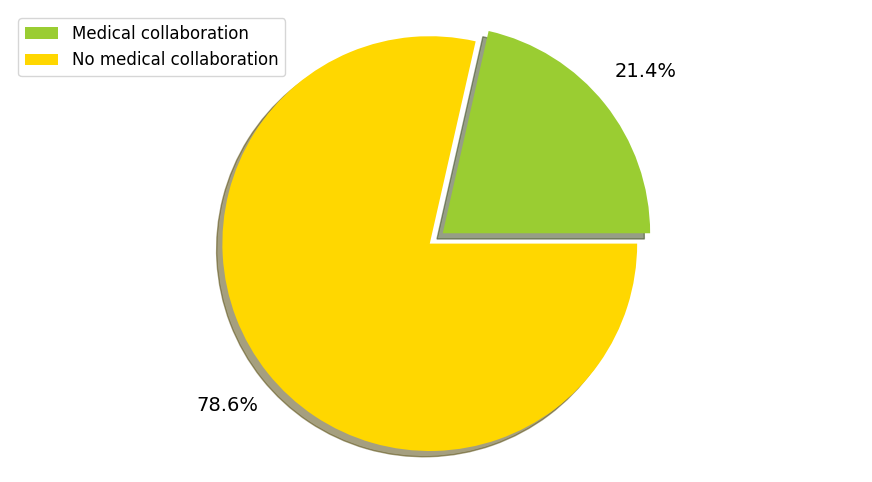

In [25]:
collab_counts = (
    publications_colaborations_df["clinical_nonclinical_collaboration"]
    .value_counts()
    .reindex([True, False], fill_value=0)
)

collab_counts.index = collab_counts.index.map({
    True: "Medical collaboration",
    False: "No medical collaboration"
})

explode_list = [0.08 if label == "Medical collaboration" else 0 for label in collab_counts.index]

colors_list = ["yellowgreen", "gold"]

collab_counts.plot(
    kind="pie",
    figsize=(11, 6),
    autopct="%1.1f%%",
    startangle=0,
    shadow=True,
    labels=None,
    pctdistance=1.25,
    colors=colors_list,
    explode=explode_list,
    textprops={"fontsize": 14}
)

plt.axis("equal")
plt.legend(labels=collab_counts.index, fontsize=12, loc="upper left")
plt.ylabel("")
plt.savefig("figures/clinical_non_clinical_colaboration.png", dpi=300, bbox_inches="tight")
plt.show()

#### **4.2 Yearly Medical-Technical Collaboration Share**
This section visualizes how the percentage of publications involving medical–technical collaboration changes over time

In [9]:
yearly_hospital_trend = (
    publications_colaborations_df
    .groupby("publication_year")
    .agg(total_papers=("openalex_id", "count"), hospital_collab_papers=("has_clinical_affiliation", "sum"))
    .reset_index()
)

yearly_hospital_trend["hospital_collab_percentage"] = yearly_hospital_trend["hospital_collab_papers"] / yearly_hospital_trend["total_papers"]

In [10]:
years, percentages = yearly_hospital_trend["publication_year"], yearly_hospital_trend["hospital_collab_percentage"]

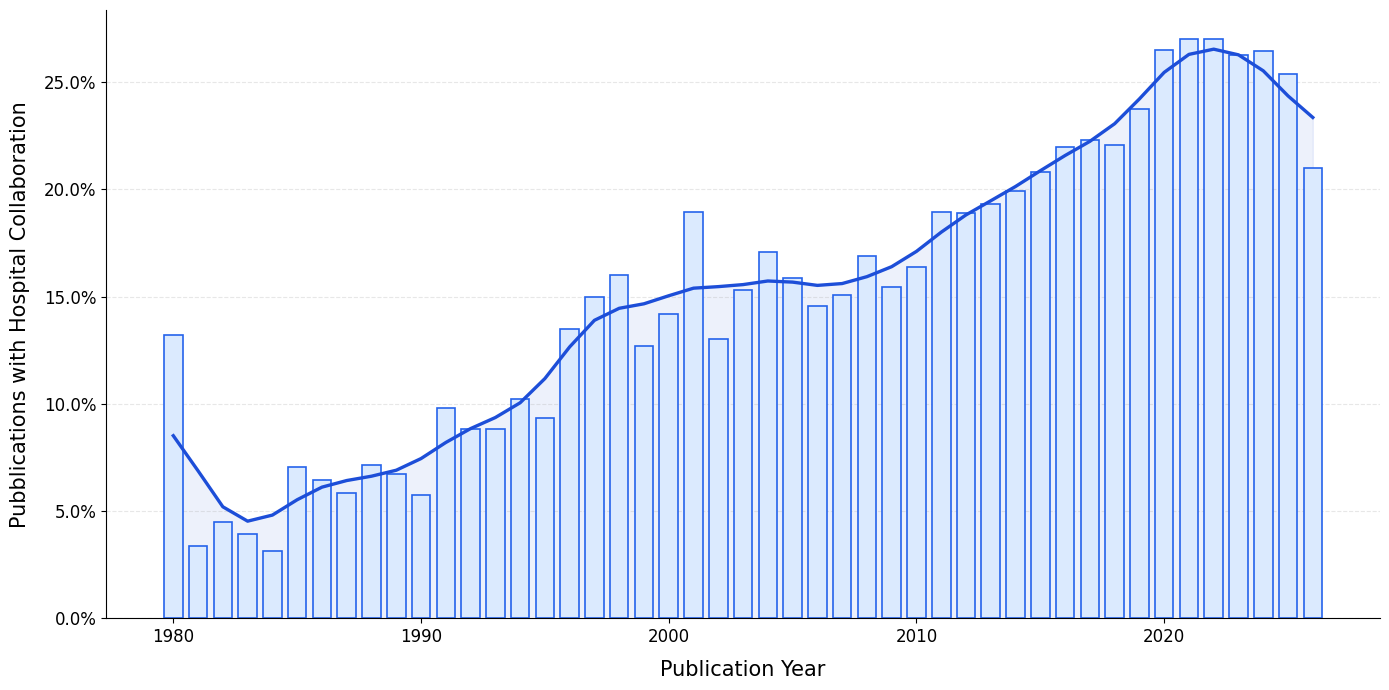

In [11]:
plot_yearly_bar_chart(
    years, 
    percentages, 
    xlabel = "Publication Year",
    ylabel = "Pubblications with Medical Collaboration",
    percentage=True,
    save_file = "figures/collaboration_growth_ai_medicine.png"
)